# E02 - The depth wall, and whether parameterization removes it

Two networks differing only in how the rectifier is written:

| | init | operator at init |
|---|---|---|
| `relu_mlp` | `xavier` | collapses exponentially with depth |
| `crelu_mlp` | `looks_linear` | exactly orthogonal, every depth, every input |

```bash
python -m olo.run configs/experiments/e02_depth_wall.yaml \
  --sweep model.depth=2,4,8,16,32,64,128,256 \
  --sweep optim.type=als,adam,heavyball,muon,kfac,shampoo,soap \
  --sweep optim.lr=0.3,0.1,0.03,0.01,0.003,0.001,0.0003 --seeds 0,1,2

python -m olo.run configs/experiments/e02_depth_wall.yaml \
  --set model.type=relu_mlp --set model.init=xavier --set name=e02_relu_xavier \
  --sweep model.depth=2,4,8,16,32,64,128,256 \
  --sweep optim.type=als,adam,heavyball,muon,kfac,shampoo,soap \
  --sweep optim.lr=0.3,0.1,0.03,0.01,0.003,0.001,0.0003 --seeds 0,1,2
```


In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from olo.viz import load_runs, depth_wall, cost, apply_style

apply_style()
crelu = load_runs("../runs", "e02_depth_wall*")
relu  = load_runs("../runs", "e02_relu_xavier*")
print(f"crelu/looks-linear: {len(crelu)} runs   relu/xavier: {len(relu)} runs")

crelu/looks-linear: 1 runs   relu/xavier: 0 runs


## Tuned performance against depth

Each point is that method's best over the entire learning-rate grid at that depth, so a
rise is a depth effect and not an untuned step size.

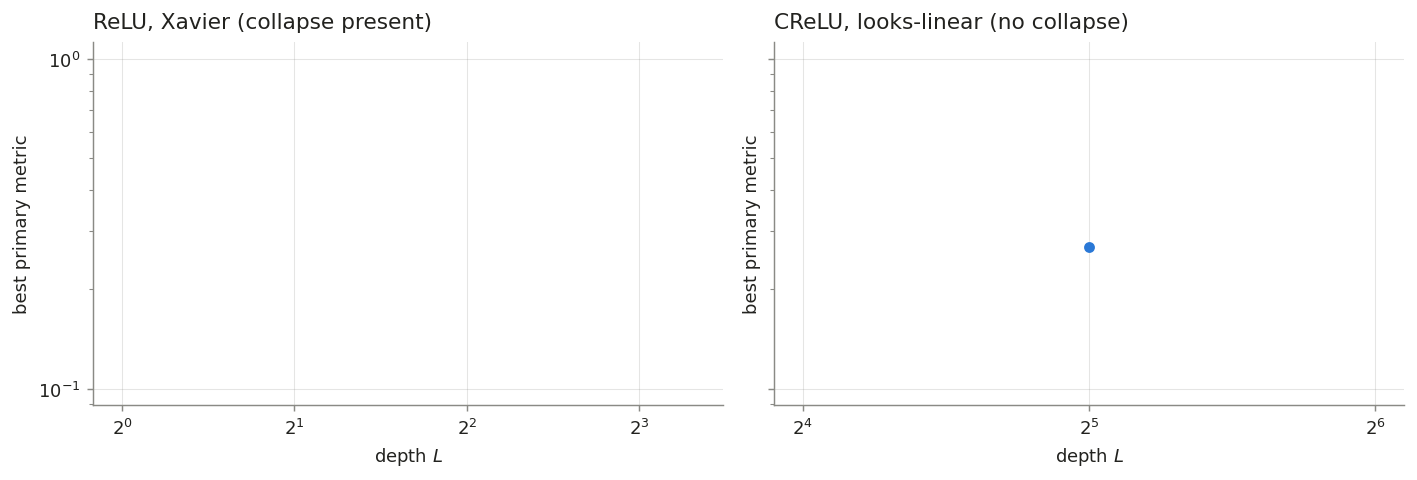

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
depth_wall(relu,  ax=axes[0], title="ReLU, Xavier (collapse present)")
depth_wall(crelu, ax=axes[1], title="CReLU, looks-linear (no collapse)")
fig.tight_layout()
fig.savefig("../figures/e02_depth_wall.pdf")

**The question this answers.** If tuned Adam tracks ALS on the right panel but not the
left, then what the earlier work measured as "depth breaks parameter-space optimizers" was
collapse, and it is removable by parameterization. If a gap survives on the right, the
residue is update-direction mismatch.

## What it costs

The exact solve is orders of magnitude more expensive per step. That belongs in the paper
as a measured number, not as a complexity class.

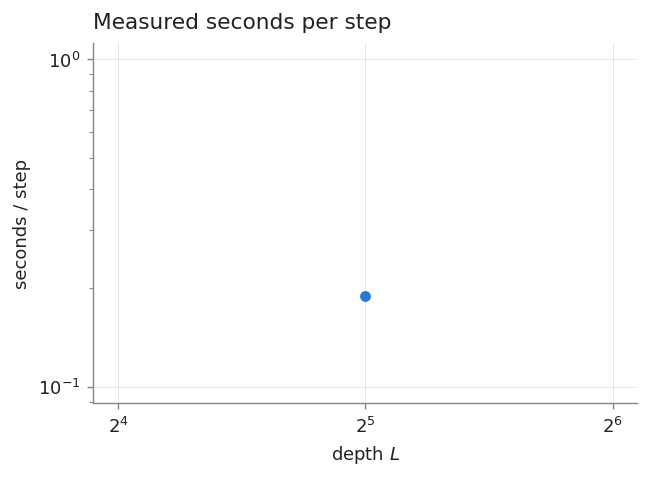

In [3]:
fig, ax = plt.subplots(figsize=(5.4, 3.6))
cost(crelu, ax=ax, title="Measured seconds per step")
fig.savefig("../figures/e02_cost.pdf")